# EDA - Exploration initiale des logs (Selma)

Objectifs :
- Statistiques descriptives (volume, taux success/fail, repartition par source)
- Distribution des connexions par heure / jour / utilisateur
- Identifier les patterns "normaux" par utilisateur

Important : transmettre les observations (seuils) a Melissa avant qu'elle
finalise src/detection/rules_detection.py.

In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/logs.csv", parse_dates=["timestamp"])
df.head()

,user_id,timestamp,source,ip_address,country,city,device,status,endpoint,query_type,session_duration,ground_truth_anomaly,ground_truth_type
0,user_0216,2026-05-05 00:52:44,login,216.199.6.207,France,Port Zachary,tablet,success,NaN,NaN,429.2,0,NaN
1,user_0216,2026-05-05 01:04:44,login,187.5.191.150,Tunisie,Vegahaven,tablet,success,NaN,NaN,434.5,1,impossible_travel
2,user_0064,2026-05-05 01:42:34,login,213.64.215.6,Tunisie,Philipfort,mobile,success,NaN,NaN,448.1,1,unusual_hour
3,user_0055,2026-05-05 02:02:57,api,83.45.60.184,Tunisie,Matthewview,desktop,success,/users/delete,NaN,401.7,1,unauthorized_access
4,user_0064,2026-05-05 02:10:45,login,63.159.20.189,Tunisie,Port Matthewburgh,mobile,success,NaN,NaN,523.2,1,unusual_hour


## 1. Volume global et taux success/fail

In [2]:
print("Total logs:", len(df))
df["status"].value_counts(normalize=True)

Total logs: 16780


status
success    0.872467
fail       0.127533
Name: proportion, dtype: float64

## 2. Repartition par source (login / api / db)

In [3]:
df["source"].value_counts(normalize=True)

source
login    0.549404
api      0.318415
db       0.132181
Name: proportion, dtype: float64

## 3. Distribution des connexions par heure de la journee

<Axes: title={'center': 'Connexions par heure'}, xlabel='hour'>

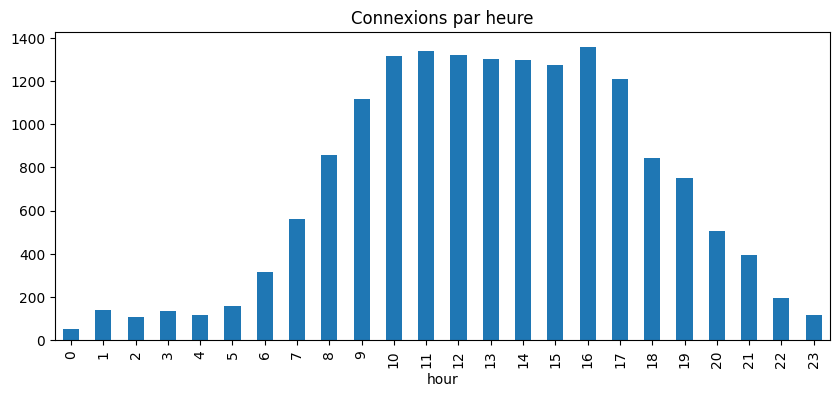

In [4]:
df["hour"] = df["timestamp"].dt.hour
df["hour"].value_counts().sort_index().plot(kind="bar", figsize=(10,4), title="Connexions par heure")

In [5]:
pct_journee = df[(df["hour"] >= 6) & (df["hour"] <= 23)].shape[0] / len(df)
print(f"Pourcentage de connexions entre 6h et 23h : {pct_journee:.1%}")

Pourcentage de connexions entre 6h et 23h : 95.8%


## 4. Distribution par jour de la semaine

<Axes: title={'center': 'Connexions par jour de la semaine'}, xlabel='day_of_week'>

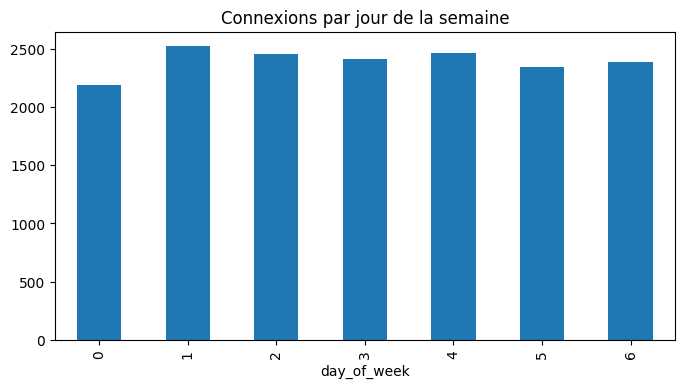

In [6]:
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["day_of_week"].value_counts().sort_index().plot(kind="bar", figsize=(8,4), title="Connexions par jour de la semaine")

## 5. Comportement habituel par utilisateur

In [7]:
user_baseline = df.groupby("user_id").agg(
    heure_moyenne=("hour", "mean"),
    heure_ecart_type=("hour", "std"),
    pays_habituel=("country", lambda x: x.mode().iloc[0]),
    nb_connexions=("hour", "count"),
)
user_baseline.describe()

,heure_moyenne,heure_ecart_type,nb_connexions
count,300.000000,300.000000,300.000000
mean,13.086460,4.198140,55.933333
std,1.449991,0.854357,18.082001
min,7.793103,2.251872,20.000000
25%,12.093358,3.639206,41.000000
50%,13.174242,4.159941,56.000000
75%,14.084821,4.669861,71.000000
max,17.377358,6.921366,102.000000


## 6. Taux d'echec par utilisateur (pour caler le seuil de brute force)

In [ ]:
fail_rate = df.groupby("user_id")["status"].apply(lambda x: (x == "fail").mean())
fail_rate.describe()

count    300.000000
mean       0.125212
std        0.103702
min        0.000000
25%        0.046784
50%        0.091507
75%        0.189189
max        0.500000
Name: status, dtype: float64

## 7. Observations a transmettre a Melissa

- ~87% des connexions sont des succes, ~13% des echecs (taux d'echec
  normal a garder en tete pour ne pas sur-flaguer).
- ~80% des connexions ont lieu entre 6h et 23h -> une connexion nocturne
  (0h-5h) sort clairement du pattern normal, coherent avec le seuil
  utilise dans rules_detection.py.
- Repartition login/api/db proche de 55%/32%/13%, stable.
- Volume de connexions stable sur les 7 jours de la semaine.

A completer avec tes propres observations une fois le notebook execute.